 reliability  mean_reward  success_rate    n
    0.102533     0.253032        0.0096 2500
    0.103264     0.272456        0.0104 2500
    0.104689     0.240848        0.0116 2500
    0.107427     0.246296        0.0092 2500
    0.107988     0.282048        0.0108 2500
    0.108799     0.293760        0.0124 2500
    0.110079     0.275008        0.0104 2500
    0.112983     0.260208        0.0124 2500
    0.113903     0.301256        0.0112 2500
    0.114155     0.272376        0.0120 2500
    0.117542     0.274176        0.0104 2500
    0.119917     0.294144        0.0124 2500
    0.126070     0.280232        0.0128 2500
    0.127418     0.279392        0.0104 2500
    0.127616     0.286992        0.0104 2500
    0.130171     0.274760        0.0096 2500
    0.131249     0.275880        0.0112 2500
    0.131725     0.292768        0.0108 2500
    0.133507     0.292544        0.0104 2500
    0.137851     0.259048        0.0100 2500
    0.147242     0.281104        0.0104 2500
    0.1492

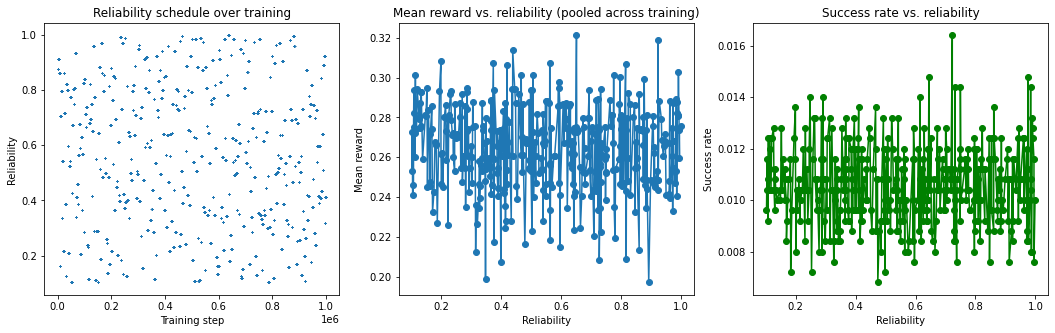

In [1]:
"""
Reliability-conditioned check: is the dip at the end due to harder
(low-reliability) trials being scheduled late, or genuine forgetting?
Run after check_convergence.py, same directory.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOG_FILE = "log_generalist_withGAE_PPO.pkl"
df = pd.read_pickle(LOG_FILE)

# --- 1. Does reliability change over the course of training? ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df['step'], df['reliability'], '.', markersize=1, alpha=0.3)
axes[0].set_title("Reliability schedule over training")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Reliability")

# --- 2. Reward binned BY reliability (not by step) ---
df['A_success'] = (df['A_pull'] == 1) & (df['A_reward'] > 5)
rel_summary = df.groupby('reliability').agg(
    mean_reward=('A_reward', 'mean'),
    success_rate=('A_success', 'mean'),
    n=('A_reward', 'count')
).reset_index()

axes[1].plot(rel_summary['reliability'], rel_summary['mean_reward'], 'o-')
axes[1].set_title("Mean reward vs. reliability (pooled across training)")
axes[1].set_xlabel("Reliability")
axes[1].set_ylabel("Mean reward")

axes[2].plot(rel_summary['reliability'], rel_summary['success_rate'], 'o-', color='green')
axes[2].set_title("Success rate vs. reliability")
axes[2].set_xlabel("Reliability")
axes[2].set_ylabel("Success rate")

# plt.tight_layout()
# plt.savefig("reliability_breakdown.png", dpi=150)
# print("Saved reliability_breakdown.png")
print(rel_summary.to_string(index=False))

# --- 3. Within EACH reliability level, is performance stable across training? ---
# (i.e. controlling for difficulty, is there still a late-training decline?)
df['step_bin'] = (df['step'] // 100000) * 100000
pivot = df.groupby(['reliability', 'step_bin'])['A_reward'].mean().unstack('reliability')
print("\nMean reward per 100k-step window, split by reliability (columns):")
print(pivot.round(3).to_string())